# Cloud-Native Earth Observation: STAC Temporal Median Composites

**Objective:** Generate cloud-free and atmospherically corrected imagery of dynamic coastal environments (Lady Elliot Island, Great Barrier Reef).
*   **The Problem:** Raw optical satellite imagery of marine environments is heavily affected by transient cloud cover, cloud shadows, sunglint, and atmospheric haze.
*   **The Solution:** This pipeline queries the Microsoft Planetary Computer STAC API for a time-series of Sentinel-2 L2A imagery. It uses `xarray` and `dask` to lazily load the data and compute a pixel-by-pixel temporal median, effectively removing clouds and filtering atmospheric noise without downloading massive data cubes locally.
*   **Key Libraries:** `pystac-client`, `odc-stac`, `xarray`, `dask`, `matplotlib`

Found 20 cloud-free images.
Computing cloud-free median composite...


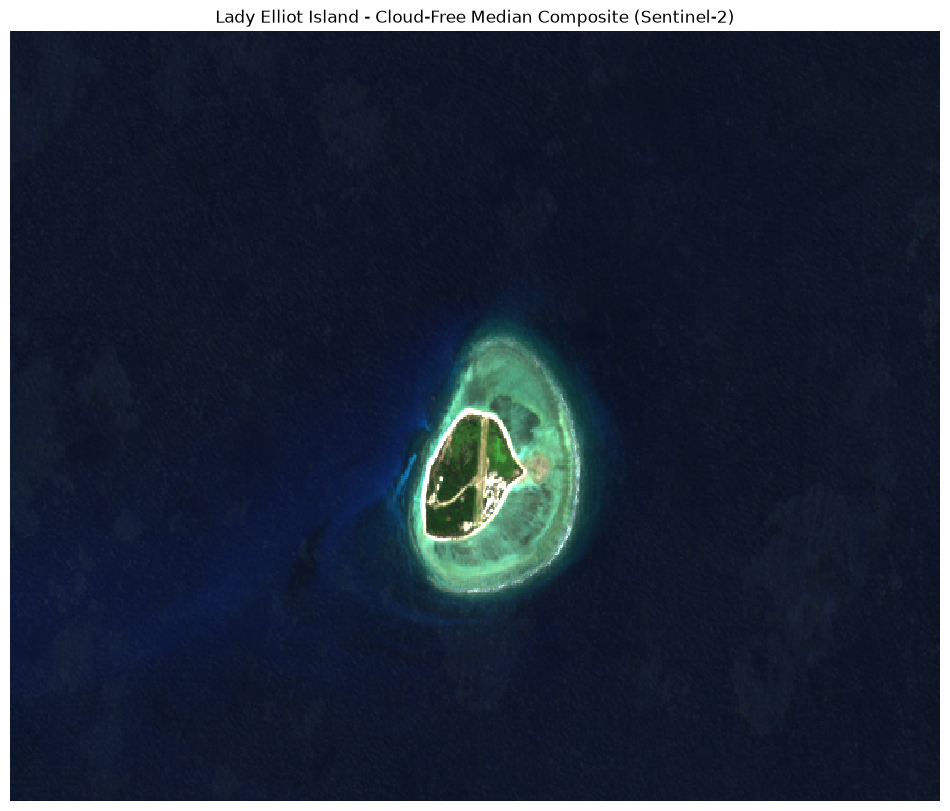

In [1]:
import pystac_client
import planetary_computer
import odc.stac
import matplotlib.pyplot as plt

# 1. Open a connection to Microsoft Planetary Computer
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# 2. Define the bounding box for Lady Elliot Island (Great Barrier Reef)
bbox = [152.68, -24.13, 152.75, -24.09]

# 3. Search the STAC catalog for cloud-free Sentinel-2 imagery
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-01-01/2026-01-01",
    query={"eo:cloud_cover": {"lt": 5}}
)
items = search.item_collection()
print(f"Found {len(items)} cloud-free images.")

# 4. Lazy-load the data into an xarray dataset
data = odc.stac.stac_load(
    items,
    bands=["red", "green", "blue"],
    bbox=bbox,
    resolution=10,
    chunks={"time": 1, "x": 2048, "y": 2048}
)

# 5. Compute the temporal median composite
# This mathematically removes transient clouds and shadows across the time series
print("Computing cloud-free median composite...")
cloud_free_composite = data.median(dim="time")

# 6. Render the pristine composite
fig, ax = plt.subplots(figsize=(12, 10))

# Raised vmin cuts the atmospheric haze. 
# Tweaked vmax keeps the coral colors vibrant without glowing.
cloud_free_composite.to_array().plot.imshow(
    vmin=1000,   
    vmax=3000,  
    ax=ax
)

plt.title("Lady Elliot Island - Cloud-Free Median Composite (Sentinel-2)")
plt.axis('off')
plt.show()